Train set size: (7165, 39) (7165,)
Test set size: (2711, 39) (2711,)
[LightGBM] [Info] Number of positive: 2208, number of negative: 4957
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8591
[LightGBM] [Info] Number of data points in the train set: 7165, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.308165 -> initscore=-0.808714
[LightGBM] [Info] Start training from score -0.808714


/tmp/ipykernel_2125246/2809348528.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x="Importance", y="Feature", palette="magma")


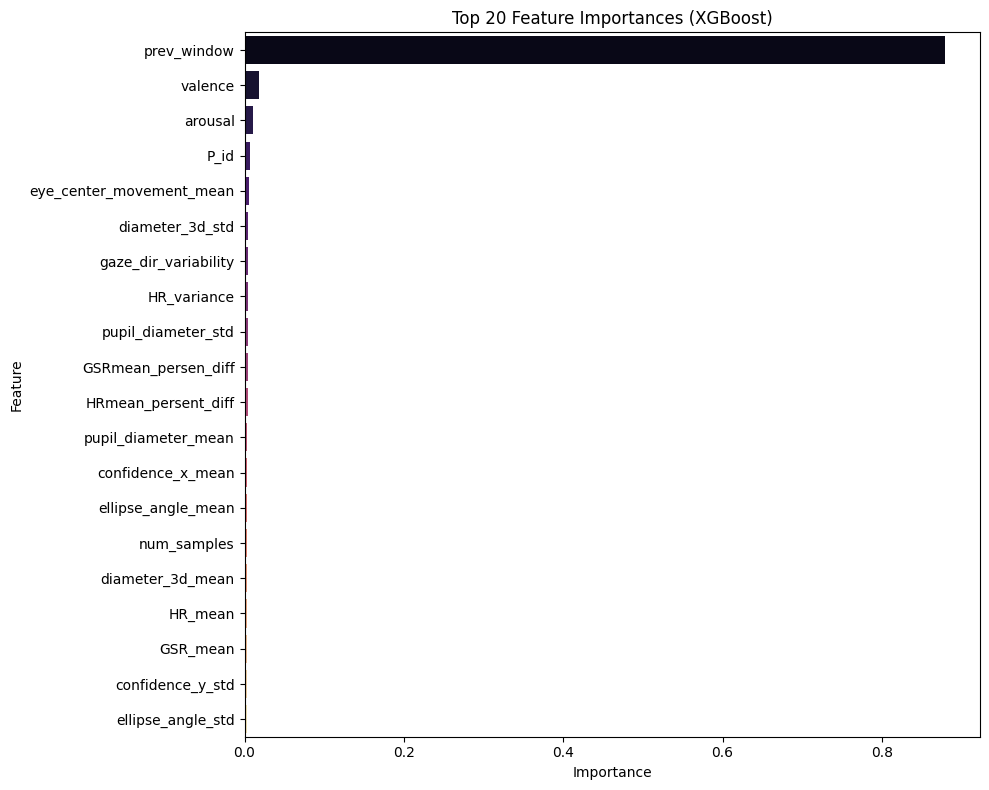

/tmp/ipykernel_2125246/2809348528.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x="Importance", y="Feature", palette="magma")


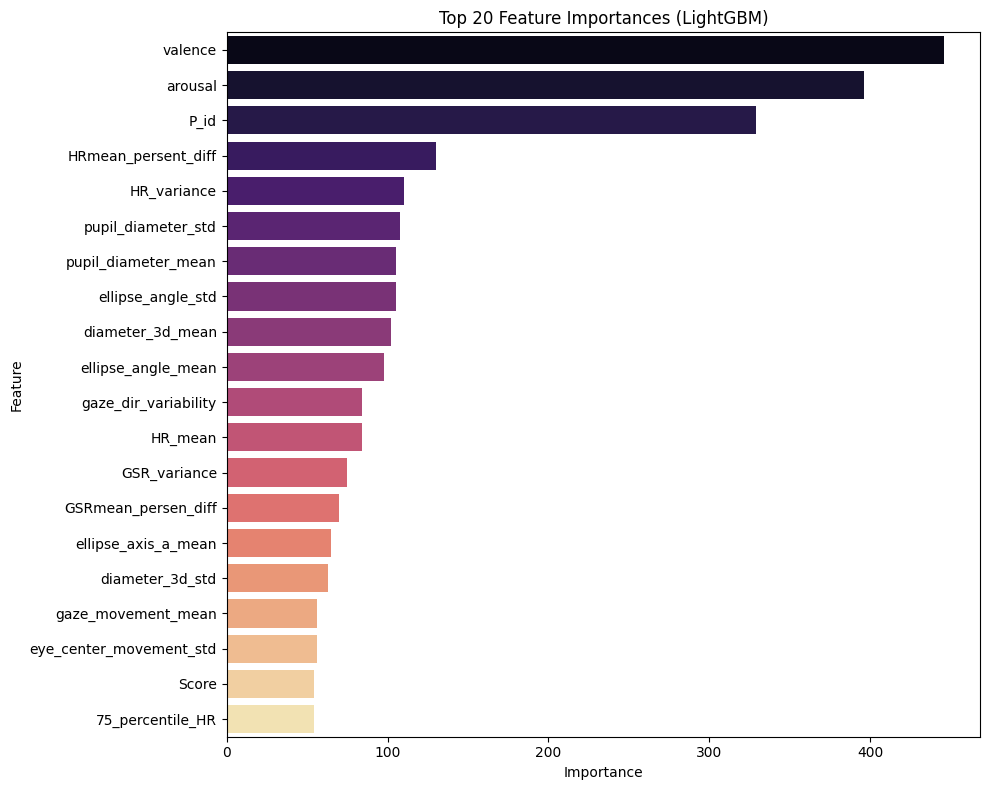


Top 10 features from XGBoost:
                     Feature  Importance
0               prev_window    0.879107
1                   valence    0.018769
2                   arousal    0.010846
3                      P_id    0.006757
4  eye_center_movement_mean    0.005370
5           diameter_3d_std    0.004729
6      gaze_dir_variability    0.004641
7               HR_variance    0.004203
8        pupil_diameter_std    0.004199
9       GSRmean_persen_diff    0.003815

Top 10 features from LightGBM:
                Feature  Importance
0              valence         446
1              arousal         396
2                 P_id         329
3  HRmean_persent_diff         130
4          HR_variance         110
5   pupil_diameter_std         108
6  pupil_diameter_mean         105
7    ellipse_angle_std         105
8     diameter_3d_mean         102
9   ellipse_angle_mean          98

XGBoost Results:
  Accuracy: 0.973
  TPR (Recall): 0.919
  FPR: 0.015
  F1-Macro: 0.955

LightGBM Results:
  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ==============================
# 1. Load and preprocess data
# ==============================
# df = pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Merge_Eye+Physio/merged_output.csv")
df = pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Final_Data_Table/merged_all_1_to_40.csv")

# Drop irrelevant columns
drop_cols = [
    'start_time', 'start_time_sec', 'start_time_ms',
    'end_time', 'end_time_sec', 'end_time_ms',
    'time', 'videoID'
]
df = df.drop(columns=drop_cols, errors='ignore')

# ==============================
# 2. Train/Test split by video_id
# ==============================
train_ids = [1, 2, 3, 4, 5, 6]
test_ids = [7, 8]

X_train = df[df["video_id"].isin(train_ids)].drop(columns=["video_id", "probe"])
y_train = df[df["video_id"].isin(train_ids)]["probe"]

X_test = df[df["video_id"].isin(test_ids)].drop(columns=["video_id", "probe"])
y_test = df[df["video_id"].isin(test_ids)]["probe"]

print("Train set size:", X_train.shape, y_train.shape)
print("Test set size:", X_test.shape, y_test.shape)

# ==============================
# 3. Train models
# ==============================
# XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

# ==============================
# 4. Feature Importances
# ==============================
def feature_importance_df(model, feature_names, model_name):
    return (
        pd.DataFrame({"Feature": feature_names, "Importance": model.feature_importances_})
        .sort_values(by="Importance", ascending=False)
        .reset_index(drop=True)
    )

xgb_df = feature_importance_df(xgb, X_train.columns, "XGBoost")
lgbm_df = feature_importance_df(lgbm, X_train.columns, "LightGBM")

# Plot function
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x="Importance", y="Feature", palette="magma")
    plt.title(f"Top {top_n} Feature Importances ({model_name})")
    plt.tight_layout()
    plt.show()

# Plot importances
plot_feature_importance(xgb_df, "XGBoost")
plot_feature_importance(lgbm_df, "LightGBM")

print("\nTop 10 features from XGBoost:\n", xgb_df.head(10))
print("\nTop 10 features from LightGBM:\n", lgbm_df.head(10))

# ==============================
# 5. Evaluation
# ==============================
def compute_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{model_name} Results:")
    print(f"  Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(f"  TPR (Recall): {tpr:.3f}")
    print(f"  FPR: {fpr:.3f}")
    print(f"  F1-Macro: {f1:.3f}")

# Predictions & metrics
xgb_preds = xgb.predict(X_test)
lgbm_preds = lgbm.predict(X_test)

compute_metrics(y_test, xgb_preds, "XGBoost")
compute_metrics(y_test, lgbm_preds, "LightGBM")
